<!-- Could you make one additional figure: 1 non-converter, 1 converter, and all survival curves for n=200 and n=30000 and frozen/fine-tuned (so 2x2x2)? -->

In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
from curve_utils import get_all_curves, draw_curves
import pandas as pd
import numpy as np
import pickle
import os

In [3]:
log_dir = '/home/berens/bep973/ifeoma_home/leverage-data/log_dir'
CLEANED_FILE = 'areds_new_results_cleaned_03_06_26_split_id_11042026.csv'
CHKPT_DIR= chkpt_dir ='/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/checkpoints/npj_june_areds'
root_dir = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/areds/datasets'
stylef = '/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/survival_on_embedding/utils/berenslab.mplstyle'
RESULTS_DIR = '/home/berens/bep973/ifeoma_home/leverage-data/results'
csv_dir = os.path.dirname(root_dir)
print(csv_dir)
split_id = 11042026

/home/berens/bep973/ifeoma_home/survival_modeling/survival_on_embedding/areds


## Prelim

In [3]:
surv_log_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
surv_log_df.head(2)

,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [5]:
ex1 = surv_log_df.iloc[0]
ex1

Name                   testrun_False_FE_False_100_linear_2026-06-15_1...
State                                                           finished
Notes                                                                  -
User                                                                 NaN
Tags                                                                 NaN
                                             ...                        
val/ibs                                                          0.08436
val/ibs_best                                                    0.084258
val/mean_auroc                                                  0.772707
val/mean_auroc_best                                             0.762622
summary                                                 simclr_inet_nako
Name: 0, Length: 71, dtype: object

In [6]:
log_file_path = os.path.join(chkpt_dir, ex1['Name'])
os.listdir(log_file_path)

['config.yaml', 'val_survival_curves.csv', 'test_survival_curves.csv']

In [7]:
surv_curves = pd.read_csv(os.path.join(log_file_path, 'test_survival_curves.csv'))
surv_curves.head()

,survival_curve,event,duration,image_name
0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg
1,[0.97084301 0.95361841 0.94389343 0.93204765 0...,tensor(0.),tensor(16),55353_06_F2_LE_LS.jpg
2,[0.97136529 0.95444193 0.94488457 0.93324055 0...,tensor(0.),tensor(14),55353_08_F2_LE_RS.jpg
3,[0.97631802 0.96226443 0.95430851 0.94459649 0...,tensor(0.),tensor(12),55353_10_F2_LE_RS.jpg
4,[0.97210068 0.9556019 0.94628096 0.93492166 0...,tensor(0.),tensor(10),55353_12_F2_LE_RS.jpg


In [8]:
surv_curves['ID'] = surv_curves['image_name'].apply(lambda x : x.split('_')[0])
surv_curves['visit_number'] = surv_curves['image_name'].apply(lambda x : x.split('_')[1])
surv_curves['image_side'] = surv_curves['image_name'].apply(lambda x : x.split('_')[-2])
surv_curves.head()

,survival_curve,event,duration,image_name,ID,visit_number,image_side
0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg,55353,04,LE
1,[0.97084301 0.95361841 0.94389343 0.93204765 0...,tensor(0.),tensor(16),55353_06_F2_LE_LS.jpg,55353,06,LE
2,[0.97136529 0.95444193 0.94488457 0.93324055 0...,tensor(0.),tensor(14),55353_08_F2_LE_RS.jpg,55353,08,LE
3,[0.97631802 0.96226443 0.95430851 0.94459649 0...,tensor(0.),tensor(12),55353_10_F2_LE_RS.jpg,55353,10,LE
4,[0.97210068 0.9556019 0.94628096 0.93492166 0...,tensor(0.),tensor(10),55353_12_F2_LE_RS.jpg,55353,12,LE


In [9]:
surv_curves_plot = surv_curves[surv_curves['image_side']=='LE'].reset_index()
surv_curves_plot.head(1)

,index,survival_curve,event,duration,image_name,ID,visit_number,image_side
0,0,[0.97136709 0.95444475 0.94488797 0.93324464 0...,tensor(0.),tensor(18),55353_04_F2_LE_RS.jpg,55353,04,LE


In [10]:
to_plot = surv_curves_plot.loc[10]
to_plot

index                                                            20
survival_curve    [0.97345673 0.95774227 0.94885854 0.93802622 0...
event                                                    tensor(1.)
duration                                                  tensor(0)
image_name                                    57209_04_F2_LE_LS.jpg
ID                                                            57209
visit_number                                                     04
image_side                                                       LE
Name: 10, dtype: object

In [11]:
s = surv_curves_plot.loc[10, 'survival_curve']
values = [float(x) for x in s.strip('[]').split()]
values

[0.97345673, 0.95774227, 0.94885854, 0.93802622, 0.92560254]

In [23]:
metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()


/tmp/ipykernel_1609510/1714322262.py:1: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1001,1001_left,1001_left_RS_04,4,left,F2,RS,51685_04_F2_LE_RS.jpg,51685/51685_04_F2_LE_RS.jpg,3.0,...,4.0,N,N,6.0,N,74.4,1001_left,1001_left_4,16,0
1,1001,1001_left,1001_left_LS_06,6,left,F2,LS,51685_06_F2_LE_LS.jpg,51685/51685_06_F2_LE_LS.jpg,3.0,...,4.0,N,N,6.0,N,75.4,1001_left,1001_left_6,14,0
2,1001,1001_left,1001_left_LS_08,8,left,F2,LS,51685_08_F2_LE_LS.jpg,51685/51685_08_F2_LE_LS.jpg,2.0,...,4.0,N,N,6.0,N,76.4,1001_left,1001_left_8,12,0
3,1001,1001_left,1001_left_RS_10,10,left,F2,RS,51685_10_F2_LE_RS.jpg,51685/51685_10_F2_LE_RS.jpg,4.0,...,4.0,N,N,6.0,N,77.5,1001_left,1001_left_10,10,0
4,1001,1001_left,1001_left_LS_14,14,left,F2,LS,51685_14_F2_LE_LS.jpg,51685/51685_14_F2_LE_LS.jpg,6.0,...,4.0,N,N,6.0,N,80.1,1001_left,1001_left_14,6,0


In [24]:
patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(root_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test

,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
11137,G617,G617_right,G617_right_RS_08,8,right,F2,RS,53179_08_F2_RE_RS.jpg,53179/53179_08_F2_RE_RS.jpg,5.0,...,4.0,N,N,6.0,Y,72.8,G617_right,G617_right_8,8,0
11138,G617,G617_right,G617_right_LS_10,10,right,F2,LS,53179_10_F2_RE_LS.jpg,53179/53179_10_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,73.8,G617_right,G617_right_10,6,0
11139,G617,G617_right,G617_right_LS_12,12,right,F2,LS,53179_12_F2_RE_LS.jpg,53179/53179_12_F2_RE_LS.jpg,5.0,...,4.0,N,N,6.0,Y,75.0,G617_right,G617_right_12,4,0
11140,G617,G617_right,G617_right_LS_14,14,right,F2,LS,53179_14_F2_RE_LS.jpg,53179/53179_14_F2_RE_LS.jpg,8.0,...,4.0,N,N,6.0,Y,76.0,G617_right,G617_right_14,2,0


In [25]:
test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
test_grp['n_img'].value_counts()

n_img
10    273
1     246
9     243
8     171
5     144
4     139
6     135
11    108
7     108
2      94
3      83
12     12
Name: count, dtype: int64

In [27]:
test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
test_grp['has_event'].value_counts()

has_event
False    1368
True      388
Name: count, dtype: int64

In [28]:
sample0_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == True)].reset_index(drop = False)
num0 = 13#random.randint(0,(len(sample_)-1))\n",
print(num0)

13


In [29]:
all_images_to_plot0 =  sample0_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot0

image_path             [4074/4074_00_RE_F2_LS.jpg, 4074/4074_04_RE_F2...
diagnosis_amd_grade                           [6.0, 7.0, 7.0, 7.0, 11.0]
patient_id                                [4074, 4074, 4074, 4074, 4074]
visit_number                                            [0, 4, 6, 8, 10]
Name: 13, dtype: object

## Plot

In [ ]:
import random

In [4]:
METADATA_CSV = os.path.join(root_dir,'surv_jul_data0_11_04_26.csv')
areds_df = pd.read_csv(METADATA_CSV)
df_ssl = areds_df.sort_values(['eye_id', 'visit_number']).groupby(['eye_id']).agg(list).reset_index()


/tmp/ipykernel_1872072/4165426703.py:2: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  areds_df = pd.read_csv(METADATA_CSV)


In [ ]:
metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()

patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(root_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
# get the test set
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)



In [ ]:
test_grp = test.sort_values(['visit_number']).groupby(['eye_id', 'image_eye']).agg(list)
test_grp['n_img'] = test_grp['image_side'].apply(lambda x: len(x))
test_grp['n_img'].value_counts()
test_grp['has_event'] = test_grp['event'].apply(lambda x: 1 in x)
test_grp['has_event'].value_counts()
sample_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == True)].reset_index(drop = False)
num0 = random.randint(0,(len(sample_)-1))
print(num0)
all_images_to_plot0 =  sample_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot = all_images_to_plot0['image_path']
all_images_to_plot

In [ ]:
sample1_ = test_grp[(test_grp['n_img'] == 5) & (test_grp['has_event'] == False)].reset_index(drop = False)
num1 = random.randint(0,(len(sample1_)-1))

In [76]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


In [59]:
dfl = or_df[(or_df['freeze_encoder'] == 1) & (or_df['survival_head'] == 'mlp') & (or_df['train_size'] == 500)]
dfl_ssl = dfl.groupby(['weights_path']).agg(list)

dfl_ssl['model'] = dfl_ssl['summary'].apply(lambda x: x[0])
model_list = sorted(list(dfl_ssl['model'].unique()))
model_list
dfl_ssl['best_idx'] = dfl_ssl['test/ibs'].apply(lambda x: np.argmin(np.array(x)) )

dfl_ssl['best_result'] = dfl_ssl.apply(lambda row: row['Name'][row['best_idx']], axis=1)
dfl_ssl['best_result'].head()


weights_path
dino_meta          testrun_False_FE_True_500_mlp_2026-06-01_12-17-31
dino_nako          testrun_False_FE_True_500_mlp_2026-06-07_18-17-44
nako_mae           testrun_False_FE_True_500_mlp_2026-06-01_22-17-38
resnet_imagenet    testrun_False_FE_True_500_mlp_2026-06-09_15-10-33
retfound           testrun_False_FE_True_500_mlp_2026-06-01_07-02-54
Name: best_result, dtype: str

In [ ]:
curves_dict0= get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)


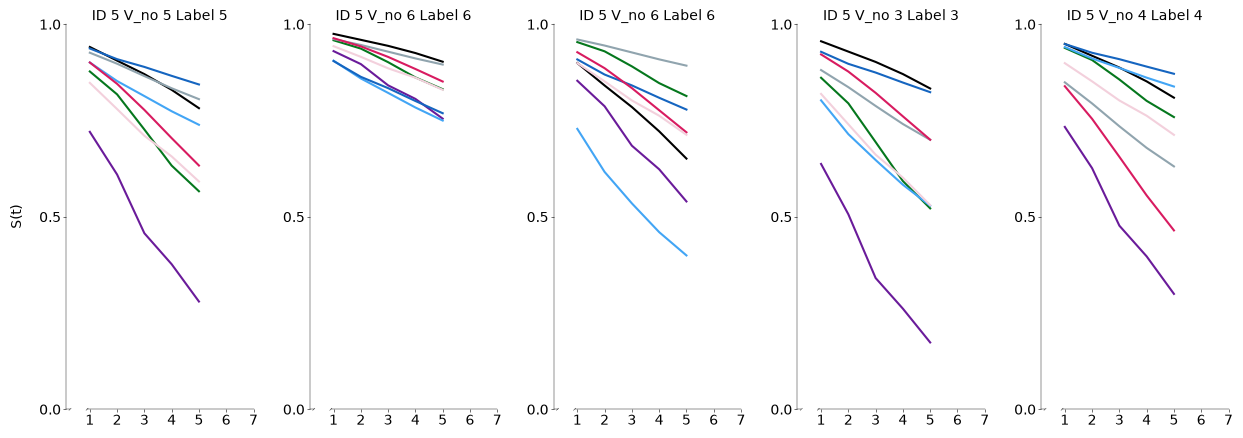

In [64]:
draw_curves(all_images_to_plot, 
            curves_dict0,
            save_path = RESULTS_DIR, 
            first_conversion_idx =3,
            marker_panel_idx = 1,
            stylef = stylef)

In [65]:
all_images_to_plot

['56634/56634_04_F2_LE_RS.jpg',
 '56634/56634_06_F2_LE_LS.jpg',
 '56634/56634_08_F2_LE_LS.jpg',
 '56634/56634_10_F2_LE_LS.jpg',
 '56634/56634_12_F2_LE_RS.jpg']

Could you make one additional figure: 1 non-converter, 1 converter, 
and all survival curves for n=200 and n=30000 and frozen/fine-tuned (so 2x2x2)?

In [66]:
all_images_to_plot0 =  sample_.loc[num0, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot = all_images_to_plot0['image_path']
all_images_to_plot

['56634/56634_04_F2_LE_RS.jpg',
 '56634/56634_06_F2_LE_LS.jpg',
 '56634/56634_08_F2_LE_LS.jpg',
 '56634/56634_10_F2_LE_LS.jpg',
 '56634/56634_12_F2_LE_RS.jpg']

In [67]:
all_images_to_plot1 =  sample1_.loc[num1, ['image_path', 'diagnosis_amd_grade', 'patient_id', "visit_number"]]
all_images_to_plot1 = all_images_to_plot1['image_path']
all_images_to_plot1

['58777/58777_04_F2_RE_RS.jpg',
 '58777/58777_06_F2_RE_LS.jpg',
 '58777/58777_08_F2_RE_LS.jpg',
 '58777/58777_10_F2_RE_RS.jpg',
 '58777/58777_12_F2_RE_RS.jpg']

In [ ]:
curves_dict0= get_all_curves(all_images_to_plot, model_list, dfl_ssl, CHKPT_DIR)
curves_dict1= get_all_curves(all_images_to_plot1, model_list, dfl_ssl, CHKPT_DIR)

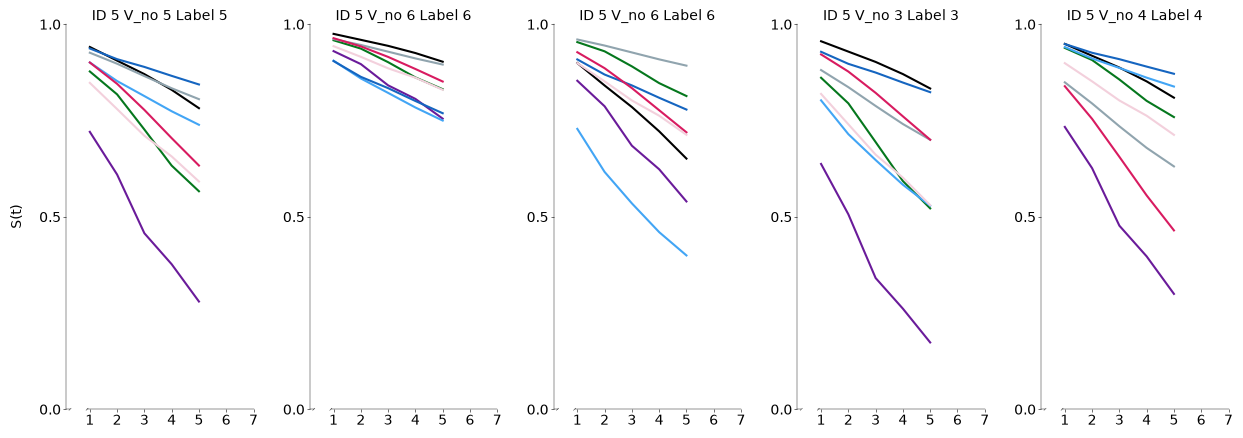

In [69]:
draw_curves(all_images_to_plot, 
            curves_dict0,
            save_path = RESULTS_DIR, 
            first_conversion_idx =3,
            marker_panel_idx = 1,
            stylef = stylef)

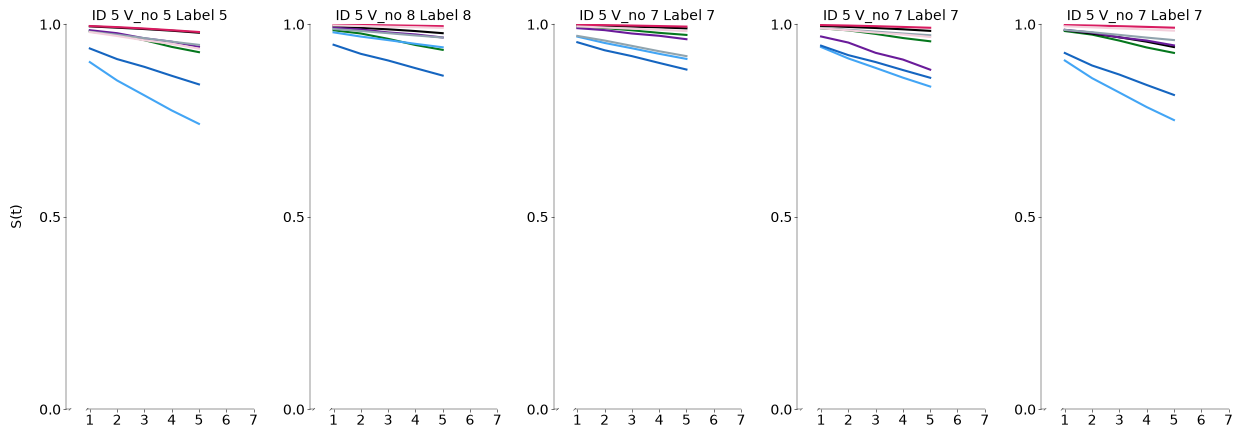

In [70]:
draw_curves(all_images_to_plot1, 
            curves_dict1,
            save_path = RESULTS_DIR, 
            first_conversion_idx =3,
            marker_panel_idx = 1,
            stylef = stylef)

## Figure 6

In [4]:

import os
import random
import contextlib
import numpy as np
from argparse import ArgumentParser
from datetime import datetime
import pandas as pd
from pathlib import Path
import numpy as np
import os
from omegaconf import OmegaConf
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib import gridspec
from brokenaxes import brokenaxes
from matplotlib.legend_handler import HandlerLine2D
from curve_utils import plot_one_image_curve, plot_one_image_curve, draw_curves_all_patients, draw_curves_grid

In [5]:
metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))
metadata_df.head()

patient_identifier= 'patient_id'
SPLIT_ID = 11042026
split_ids_file = os.path.join(root_dir, f"splits_patient-ids-{SPLIT_ID}.pkl")
dict_seed_splits_patientids = pickle.load(open(split_ids_file, "rb"))
# get the test set
test = metadata_df[metadata_df[patient_identifier].isin(dict_seed_splits_patientids[SPLIT_ID]["test"])].reset_index(drop=True)
test.head()

/tmp/ipykernel_3347640/379113036.py:1: DtypeWarning: Columns (0: patient_id) have mixed types. Specify dtype option on import or set low_memory=False.
  metadata_df = pd.read_csv(os.path.join(root_dir,'surv_jul_data0_11_04_26.csv'))


,patient_id,eye_id,image_id,visit_number,image_eye,image_field,image_side,image_file,image_path,diagnosis_amd_grade,...,clinical_treatment_category,clinical_laser_photocoagulation_right,clinical_laser_photocoagulation_left,diagnosis_final_amd_status,clinical_centrum_intake,patient_age,sequence_id,observation_id,duration,event
0,1006,1006_left,1006_left_RS_04,4,left,F2,RS,55353_04_F2_LE_RS.jpg,55353/55353_04_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,69.3,1006_left,1006_left_4,18,0
1,1006,1006_left,1006_left_LS_06,6,left,F2,LS,55353_06_F2_LE_LS.jpg,55353/55353_06_F2_LE_LS.jpg,2.0,...,4.0,N,N,14.0,N,70.3,1006_left,1006_left_6,16,0
2,1006,1006_left,1006_left_RS_08,8,left,F2,RS,55353_08_F2_LE_RS.jpg,55353/55353_08_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,71.3,1006_left,1006_left_8,14,0
3,1006,1006_left,1006_left_RS_10,10,left,F2,RS,55353_10_F2_LE_RS.jpg,55353/55353_10_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,72.2,1006_left,1006_left_10,12,0
4,1006,1006_left,1006_left_RS_12,12,left,F2,RS,55353_12_F2_LE_RS.jpg,55353/55353_12_F2_LE_RS.jpg,1.0,...,4.0,N,N,14.0,N,73.2,1006_left,1006_left_12,10,0


In [ ]:
or_df = pd.read_csv(os.path.join(log_dir, f'{CLEANED_FILE}'))
print(or_df.shape)
or_df.head(2)

(1120, 71)


,Name,State,Notes,User,Tags,Created,Runtime,Sweep,backbone_model_str,batch_size,...,val/brier_score_t4,val/brier_score_t6,val/brier_score_t8,val/brier_scores,val/concordance_index,val/ibs,val/ibs_best,val/mean_auroc,val/mean_auroc_best,summary
0,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T14:08:16.000Z,5317,NaN,simclr_inet_nako,8,...,0.070489,0.084390,0.098673,"[0.055670785775393986,0.0704893362169278,0.084...",0.763673,0.084360,0.084258,0.772707,0.762622,simclr_inet_nako
1,testrun_False_FE_False_100_linear_2026-06-15_1...,finished,-,NaN,NaN,2026-06-15T12:23:46.000Z,6238,NaN,simclr_inet_nako,8,...,0.066882,0.077552,0.088270,"[0.05255887579501174,0.06688229519199841,0.077...",0.820761,0.077198,0.077987,0.829780,0.825683,simclr_inet_nako


## Single

In [ ]:
dict1, img_to_plot = plot_one_image_curve(or_df, test, freeze_encoder = 1, train_size = 500, num_images = 2, CHKPT_DIR=CHKPT_DIR)

## Collective 

In [7]:
info_dict = [
        {'freeze_encoder': 1, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 1, 'train_size': 500, 'has_event': False},
        {'freeze_encoder': 1, 'train_size': 30000, 'has_event': True},
        {'freeze_encoder': 1, 'train_size': 30000, 'has_event': False},

        {'freeze_encoder': 0, 'train_size': 500, 'has_event': True},
        {'freeze_encoder': 0, 'train_size': 500, 'has_event': False},
        {'freeze_encoder': 0, 'train_size': 30000, 'has_event': True},
        {'freeze_encoder': 0, 'train_size': 30000, 'has_event': False},

            ]


In [8]:
records = []

for i, vals in enumerate(info_dict):
    freeze_encoder = vals['freeze_encoder']
    train_size = vals['train_size']
    has_event = vals['has_event']

    dict1, img_to_plot = plot_one_image_curve(
        or_df, test, freeze_encoder=freeze_encoder,
        train_size=train_size, num_images=2, has_event=has_event,
        CHKPT_DIR=CHKPT_DIR, num0=15
    )

    records.append({
        'freeze_encoder': freeze_encoder,
        'train_size': train_size,
        'has_event': has_event,
        'patient_id': img_to_plot['patient_id'][0] if isinstance(img_to_plot['patient_id'], list) else img_to_plot['patient_id'],
        'image_path': img_to_plot['image_path'][0] if isinstance(img_to_plot['image_path'], list) else img_to_plot['image_path'],
        'diagnosis_amd_grade': img_to_plot['diagnosis_amd_grade'][0] if isinstance(img_to_plot['diagnosis_amd_grade'], list) else img_to_plot['diagnosis_amd_grade'],
        'visit_number': img_to_plot['visit_number'][0] if isinstance(img_to_plot['visit_number'], list) else img_to_plot['visit_number'],

        # 'image_path': img_to_plot['image_path'],
        # 'diagnosis_amd_grade': img_to_plot['diagnosis_amd_grade'],
        # 'visit_number': img_to_plot['visit_number'],
        'curves': {model: curve[0] for model, curve in dict1.items()},  # unwrap the outer list
    })

num0 is 15
--------------------------------------

image_path             [5455/5455_10_RE_F2_RS.jpg]
diagnosis_amd_grade                         [10.0]
patient_id                                  [5455]
visit_number                                  [10]
converter                                   [True]
Name: 15, dtype: object
--------------------------------------

image_path             [5455/5455_10_RE_F2_RS.jpg]
diagnosis_amd_grade                         [10.0]
patient_id                                  [5455]
visit_number                                  [10]
converter                                   [True]
Name: 15, dtype: object
                                                           Name  \
weights_path                                                      
dino_meta     [testrun_False_FE_True_500_mlp_2026-06-11_04-4...   
dino_nako     [testrun_False_FE_True_500_mlp_2026-06-09_03-1...   
nako_mae      [testrun_False_FE_True_500_mlp_2026-06-10_21-4...   

               

In [9]:
records[0]['curves']

{'dino_meta': [0.19579625, 0.08161798, 0.01866752, 0.00333814, 0.00083337],
 'dino_nako': [0.35155183, 0.18167227, 0.09223988, 0.04045938, 0.01462913],
 'nako_mae': [0.66943641, 0.54558962, 0.38345449, 0.30258469, 0.21021273],
 'resnet_imagenet': [0.49744175, 0.34454359, 0.25194152, 0.180885, 0.13258663],
 'retfound': [0.55146555, 0.43245814, 0.3261208, 0.24430812, 0.18697086],
 'scratch': [0.92200022, 0.88807804, 0.86357074, 0.83552723, 0.80865457],
 'simclr_inet_nako': [0.86189852,
  0.78751263,
  0.69941983,
  0.6076554,
  0.52236636],
 'simclr_nako': [0.75611818, 0.65614731, 0.56037278, 0.49067331, 0.41114997]}

In [10]:
records[0]['patient_id']

'5455'

In [11]:
records[0]['visit_number']

10

In [12]:
records[0]['image_path']

'5455/5455_10_RE_F2_RS.jpg'

### individual

In [ ]:
draw_curves_all_patients(full_data, full_curves_dict, save_path=RESULTS_DIR, stylef=stylef)

### grid

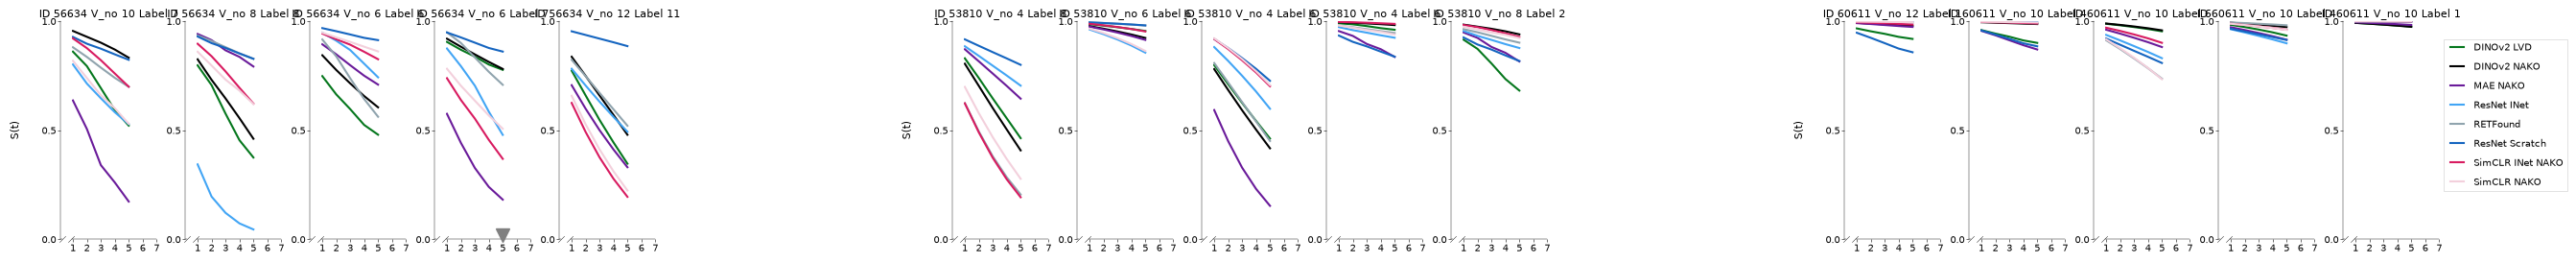

In [ ]:
draw_curves_grid(full_data, full_curves_dict, n_per_patient=5,
                  n_rows=4, n_cols=4, save_path=RESULTS_DIR, stylef=stylef)

### master single

/tmp/ipykernel_2702928/3304670082.py:87: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


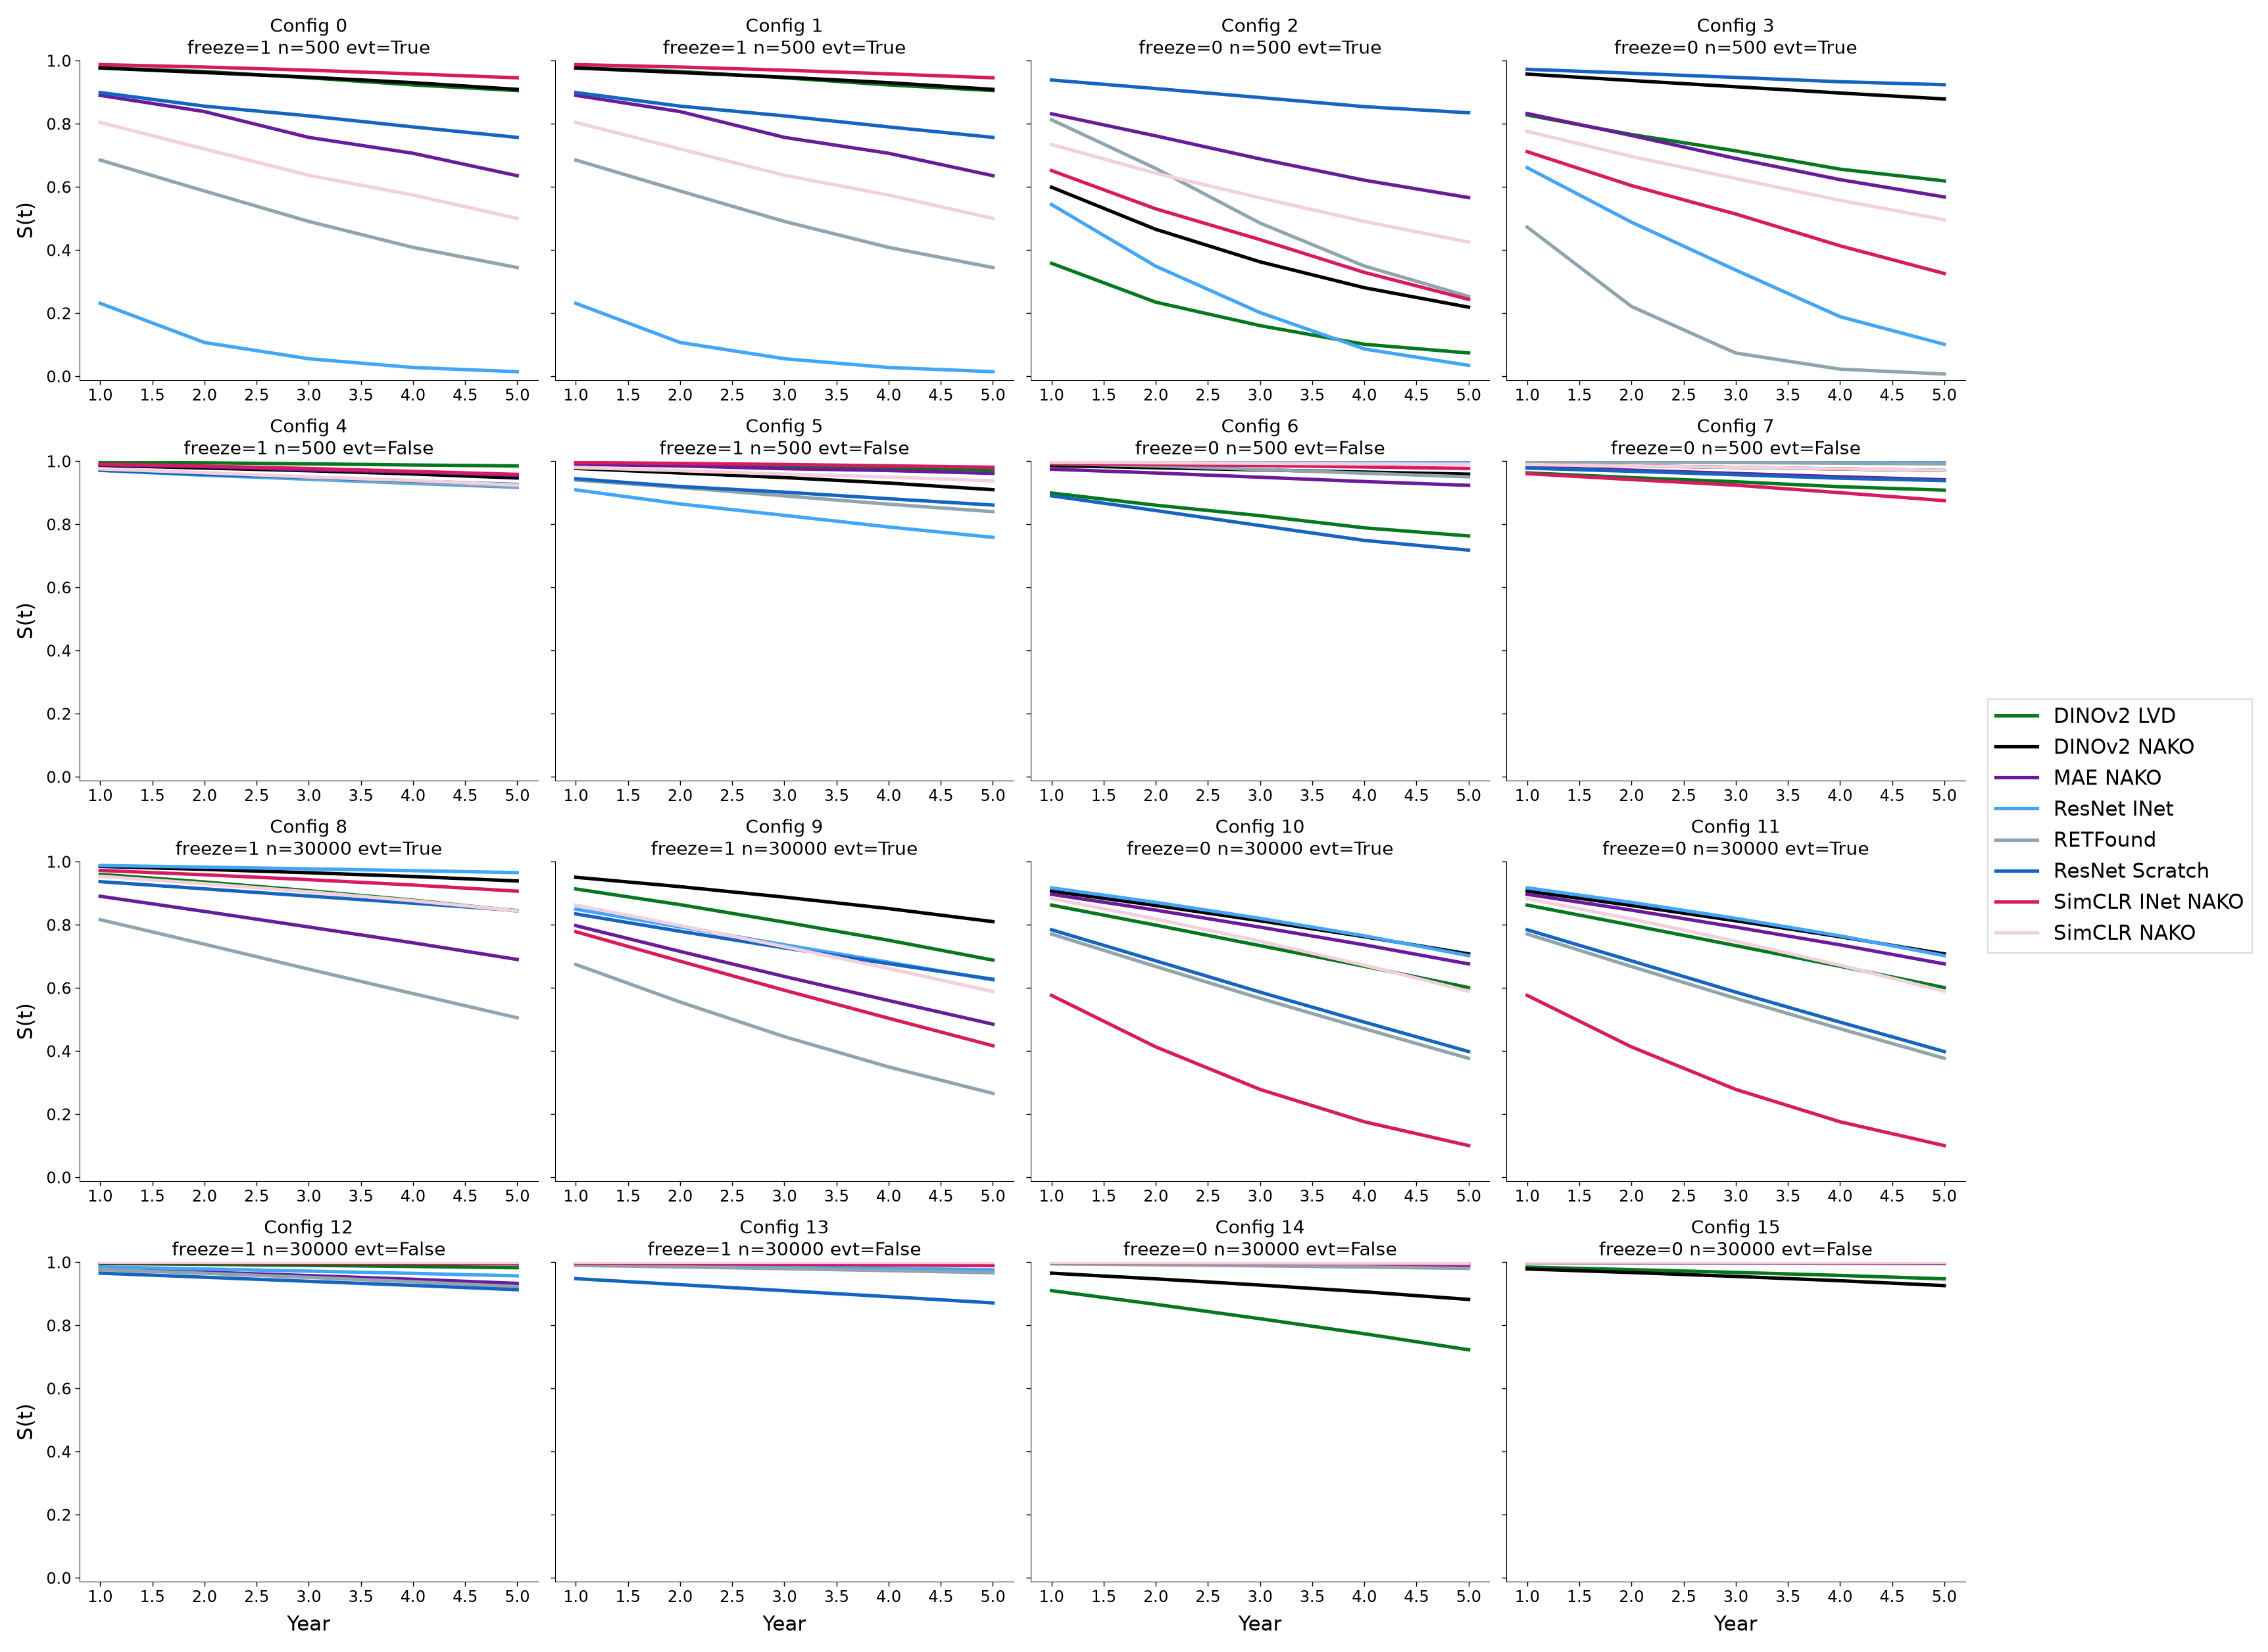

In [37]:
draw_curves_grid_simple(full_curves_dict, info_dict=info_dict, save_path=RESULTS_DIR, stylef=stylef)

### master all

In [13]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from PIL import Image

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}

In [14]:
hostname_ = 'mlcloud' 
dataset_name = 'areds'
# DATA_BASE_DIR = Path(__file__).resolve().parent
# config_file = DATA_BASE_DIR / "data/data_dirs.yaml"
# print('config file path', config_file)
# cfg = OmegaConf.load(config_file)
# project_dir = cfg['DATA'][hostname_][dataset_name]
# image_dir = f"{project_dir}"
img_dir =    '/home/berens/bep973/ifeoma_home/data/AREDS_macula/AREDS_macula'



In [16]:
# def draw_curves_grid_simple(records, image_dir=None, show_images=False,
#                              n_rows=4, n_cols=4, save_path=None, stylef=None):
#     n_patients = len(records)
#     print(records[0]['curves'])
#     y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
#     y_max = 1

#     with plt.style.context(stylef):
#         if show_images:
#             fig = plt.figure(figsize=((n_cols + 1) * 3, n_rows * 2.5))
#             outer_gs = gridspec.GridSpec(n_rows, n_cols + 1, figure=fig,
#                                           width_ratios=[1.3] + [1] * n_cols,
#                                           wspace=0.4, hspace=0.6)
#         else:
#             fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharey=True)
#             axes = axes.flatten()

#         for p, rec in enumerate(records):
#             row, col_in_row = divmod(p, n_cols)
#             ax = fig.add_subplot(outer_gs[row, col_in_row + 1]) if show_images else axes[p]

#             for model, curve in rec['curves'].items():
#                 ax.plot(range(1, len(curve) + 1), curve,
#                          label=new_names.get(model, model),
#                          color=color_groups.get(model), linewidth=1.5)

#             title = (f"ID {rec['patient_id']}\n"
#                      f"freeze={rec['freeze_encoder']} n={rec['train_size']} evt={rec['has_event']}")
#             ax.set_title(title, fontsize=8)
#             ax.set_ylim(y_min, y_max)
#             ax.tick_params(axis='both', labelsize=7)
#             if col_in_row == 0:
#                 ax.set_ylabel('S(t)', fontsize=9)
#             if row == n_rows - 1:
#                 ax.set_xlabel('Year', fontsize=9)

#             if show_images and col_in_row == n_cols - 1:
#                 img_gs = gridspec.GridSpecFromSubplotSpec(
#                     2, 2, subplot_spec=outer_gs[row, 0], wspace=0.05, hspace=0.05
#                 )
#                 row_records = records[row * n_cols: row * n_cols + n_cols]
#                 for k, r in enumerate(row_records):
#                     img_ax = fig.add_subplot(img_gs[k // 2, k % 2])
#                     img_path = os.path.join(image_dir, f"R_{r['image_path']}")
#                     img_ax.imshow(Image.open(img_path))
#                     img_ax.axis('off')

#         if not show_images:
#             for j in range(n_patients, len(axes)):
#                 axes[j].axis('off')

#         legend_ax = axes[0] if not show_images else fig.axes[0]
#         handles, labels = legend_ax.get_legend_handles_labels()
#         fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
#         plt.tight_layout()

#     if save_path is not None:
#         plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
#     plt.show()

In [35]:
def draw_curves_grid_simple(records, image_dir=None, show_images=False,
                             n_rows=4, n_cols=4, save_path=None, stylef=None):
    n_patients = len(records)
    print(records[0]['curves'])
    y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
    y_max = 1

    with plt.style.context(stylef):
        if show_images:
            fig = plt.figure(figsize=((n_cols + 1) * 3, n_rows * 2.5))
            outer_gs = gridspec.GridSpec(n_rows, n_cols + 1, figure=fig,
                                          width_ratios=[1] * n_cols + [1.3],   # CHANGED: image col width now last
                                          wspace=0.2, hspace=0.6)
        else:
            fig, axes = plt.subplots(n_rows, n_cols, figsize=(n_cols * 3, n_rows * 2.5), sharey=True)
            axes = axes.flatten()
             
        for p, rec in enumerate(records):
            row, col_in_row = divmod(p, n_cols)
            ax = fig.add_subplot(outer_gs[row, col_in_row]) if show_images else axes[p]  # CHANGED: no +1 shift

            for model, curve in rec['curves'].items():
                ax.plot(range(1, len(curve) + 1), curve,
                         label=new_names.get(model, model),
                         color=color_groups.get(model), linewidth=1.5)

            title = (f"ID {rec['patient_id']}\n"
                     f"freeze={rec['freeze_encoder']} n={rec['train_size']} cvt={rec['has_event']}")
            ax.set_title(title, fontsize=8)
            ax.set_ylim(y_min, y_max)
            ax.set_yticks([0, 0.5, 1])   # NEW

            ax.tick_params(axis='both', labelsize=7)
            if col_in_row == 0:
                ax.set_ylabel('S(t)', fontsize=9)
            if row == n_rows - 1:
                ax.set_xlabel('Year', fontsize=9)

            if show_images and col_in_row == n_cols - 1:
                img_gs = gridspec.GridSpecFromSubplotSpec(
                    2, 2, subplot_spec=outer_gs[row, n_cols], wspace=0.05, hspace=0.05  # CHANGED: image block now at col n_cols
                )
                row_records = records[row * n_cols: row * n_cols + n_cols]
                for k, r in enumerate(row_records):
                    img_ax = fig.add_subplot(img_gs[k // 2, k % 2])
                    img_path = os.path.join(image_dir, f"R_{r['image_path']}")
                    img_ax.imshow(Image.open(img_path))
                    img_ax.axis('off')

        if not show_images:
            for j in range(n_patients, len(axes)):
                axes[j].axis('off')

        # legend_ax = axes[0] if not show_images else fig.axes[0]
        # handles, labels = legend_ax.get_legend_handles_labels()
        # fig.legend(handles, labels, loc='center left', bbox_to_anchor=(1.0, 0.5), fontsize=9)
        # plt.tight_layout()
        
        legend_ax = axes[0] if not show_images else fig.axes[0]
        handles, labels = legend_ax.get_legend_handles_labels()
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.4, 0.98),
                   ncol=4, fontsize=9)
        plt.tight_layout()

        fig.subplots_adjust(bottom=0.15)  # adjust value as needed to fit the legend
# 
    if save_path is not None:
        plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
    plt.show()

In [45]:
RESULTS_DIR

'/home/berens/bep973/ifeoma_home/leverage-data/results'

{'dino_meta': [0.19579625, 0.08161798, 0.01866752, 0.00333814, 0.00083337], 'dino_nako': [0.35155183, 0.18167227, 0.09223988, 0.04045938, 0.01462913], 'nako_mae': [0.66943641, 0.54558962, 0.38345449, 0.30258469, 0.21021273], 'resnet_imagenet': [0.49744175, 0.34454359, 0.25194152, 0.180885, 0.13258663], 'retfound': [0.55146555, 0.43245814, 0.3261208, 0.24430812, 0.18697086], 'scratch': [0.92200022, 0.88807804, 0.86357074, 0.83552723, 0.80865457], 'simclr_inet_nako': [0.86189852, 0.78751263, 0.69941983, 0.6076554, 0.52236636], 'simclr_nako': [0.75611818, 0.65614731, 0.56037278, 0.49067331, 0.41114997]}


/tmp/ipykernel_3347640/2289421779.py:63: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3347640/2289421779.py:63: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


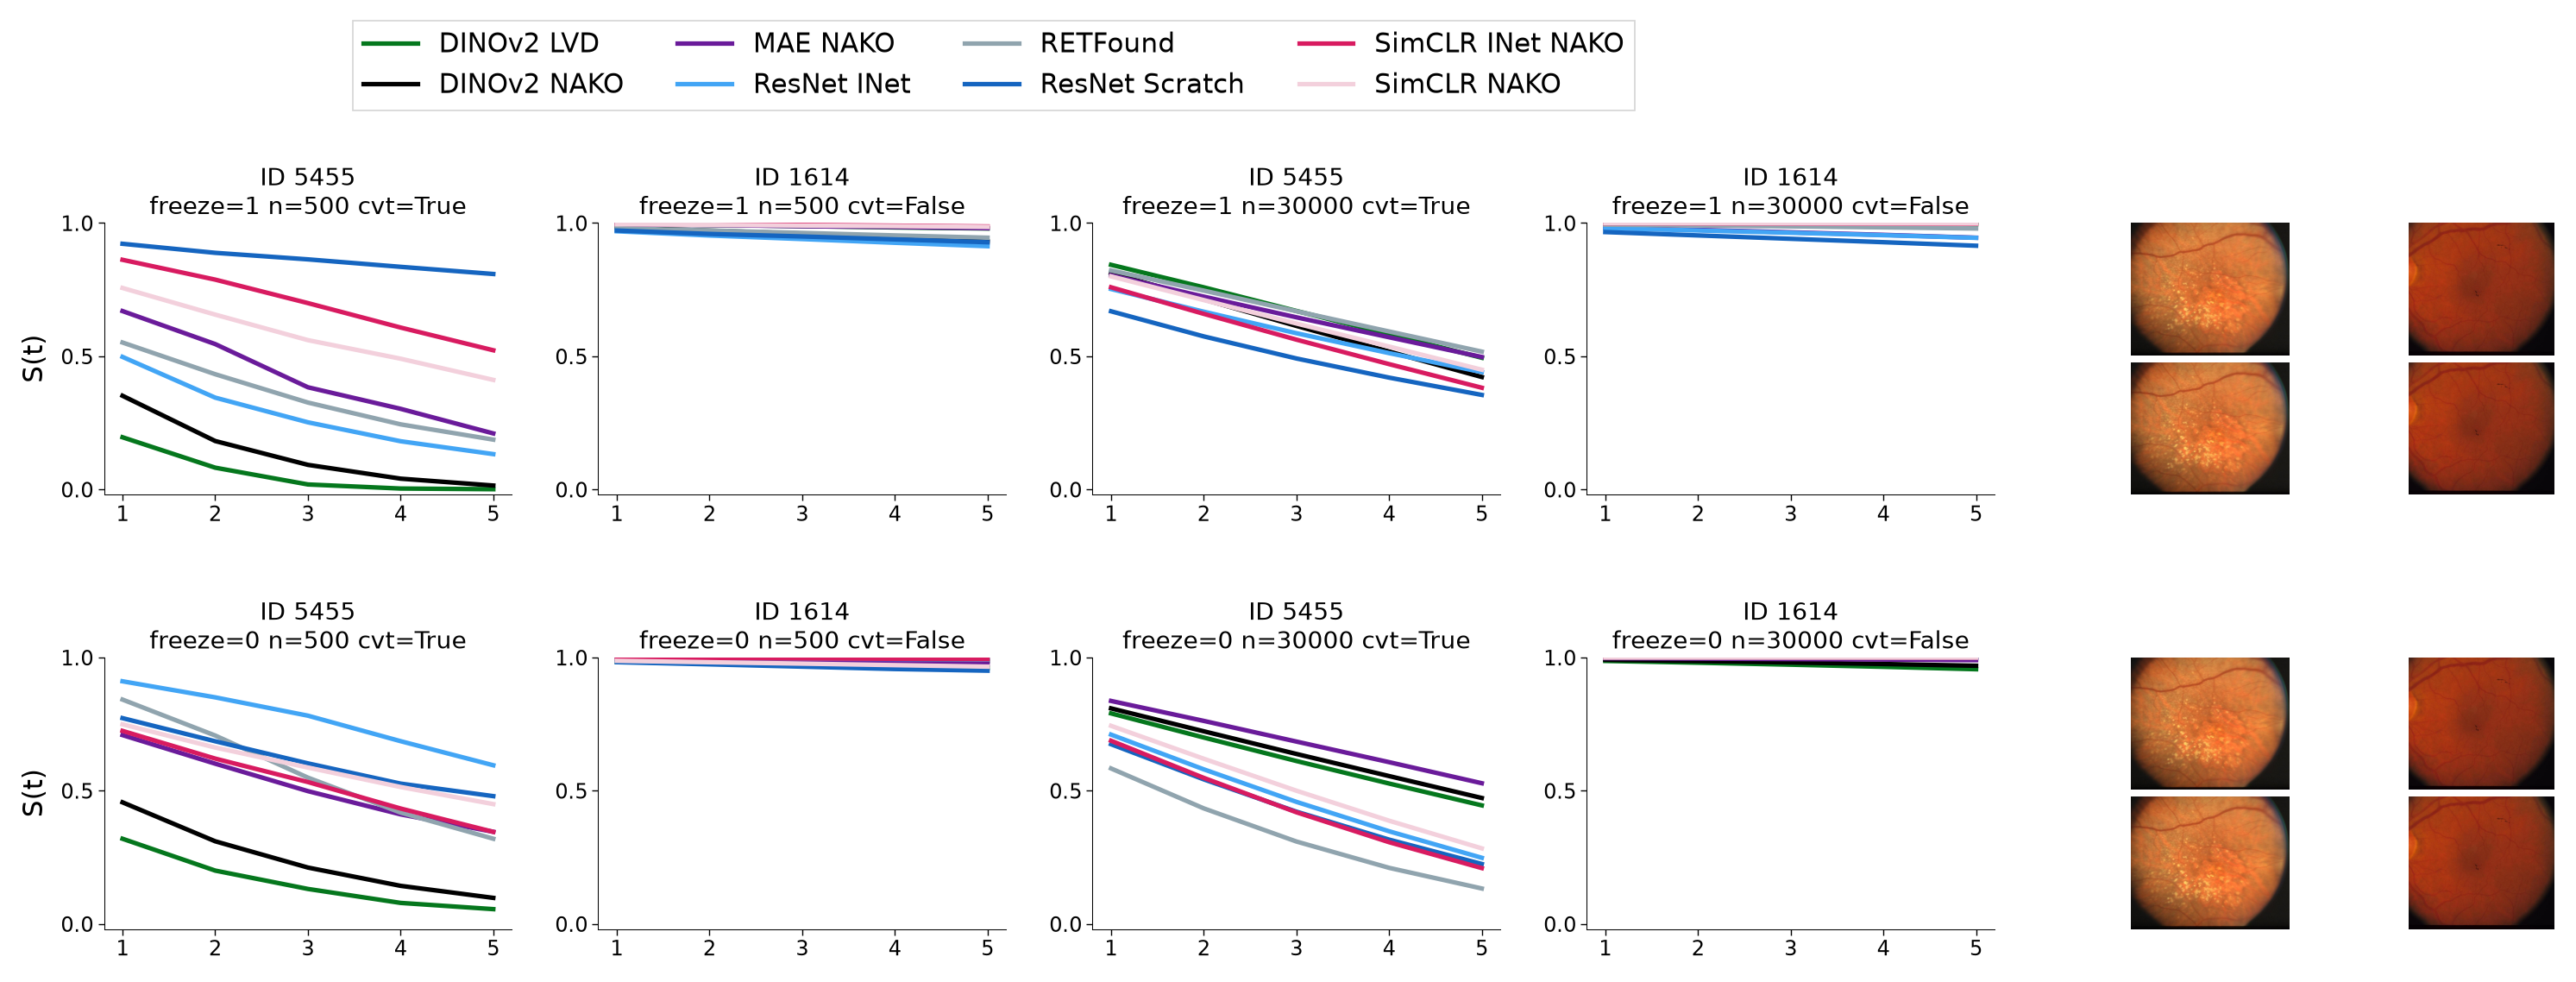

In [36]:
draw_curves_grid_simple(records, image_dir=img_dir, show_images=True,
                         save_path=RESULTS_DIR, stylef=stylef)

In [43]:
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
from brokenaxes import brokenaxes
import os
from PIL import Image

color_groups = {
    'dino_nako': '#000000', 'dino_meta': '#05771D', 'retfound': '#90A4AE',
    'nako_mae': '#6A1B9A', 'simclr_inet_nako': '#D81B60', 'simclr_nako': '#F3D0DC',
    'scratch': '#1565C0', 'resnet_imagenet': '#42A5F5',
}
new_names = {
    'dino_nako': 'DINOv2 NAKO', 'dino_meta': 'DINOv2 LVD', 'retfound': 'RETFound',
    'resnet_imagenet': 'ResNet INet', 'nako_mae': "MAE NAKO", 'simclr_nako': 'SimCLR NAKO',
    'simclr_inet_nako': 'SimCLR INet NAKO', 'scratch': "ResNet Scratch"
}

def draw_curves_grid_simple(records, image_dir=None, show_images=False,
                             n_rows=4, n_cols=4, save_path=None, stylef=None):
    n_patients = len(records)
    y_min = min(min(curve) for r in records for curve in r['curves'].values()) - 0.02
    y_max = 1

    with plt.style.context(stylef):
        # ── Build ONE figure + ONE grid layout, regardless of show_images ──
        if show_images:
            fig = plt.figure(figsize=((n_cols + 1) * 3, n_rows * 2.5))
            outer_gs = gridspec.GridSpec(n_rows, n_cols + 1, figure=fig,
                                          width_ratios=[1] * n_cols + [1.3],
                                          wspace=0.2, hspace=0.6)
        else:
            fig = plt.figure(figsize=(n_cols * 3, n_rows * 2.5))
            outer_gs = gridspec.GridSpec(n_rows, n_cols, figure=fig,
                                          wspace=0.3, hspace=0.6)

        for p, rec in enumerate(records):
            row, col_in_row = divmod(p, n_cols)
            cell = outer_gs[row, col_in_row]

            bax = brokenaxes(
                xlims=((-0.1, 0.002), (0.9, 5.1)),
                hspace=0.01, d=0.005, tilt=45,
                subplot_spec=cell,
                fig=fig
            )

            for model, curve in rec['curves'].items():
                bax.plot(range(1, len(curve) + 1), curve,
                          label=new_names.get(model, model),
                          color=color_groups.get(model), linewidth=1.5)

            title = (f"ID {rec['patient_id']}\n"
                      f"freeze={rec['freeze_encoder']} n={rec['train_size']} evt={rec['has_event']}")
            bax.set_title(title, fontsize=8)
            bax.set_ylim(y_min, y_max)
            bax.axs[1].set_yticks([0, 0.5, 1])
            bax.axs[0].set_xticks([])
            bax.axs[1].set_xticks([1, 2, 3, 4, 5])

            # restore visible left spine/ticks on the baseline mini-axis
            bax.axs[0].spines['left'].set_visible(True)
            bax.axs[0].tick_params(left=True, labelleft=True)

            for a in bax.axs:
                a.tick_params(axis='both', labelsize=7)

            if col_in_row == 0:
                bax.set_ylabel('S(t)', fontsize=9)
            if row == n_rows - 1:
                bax.set_xlabel('Year', fontsize=9)

            # ── image block for this row, drawn once after last curve column ──
            if show_images and col_in_row == n_cols - 1:
                img_gs = gridspec.GridSpecFromSubplotSpec(
                    2, 2, subplot_spec=outer_gs[row, n_cols], wspace=0.05, hspace=0.05
                )
                row_records = records[row * n_cols: row * n_cols + n_cols]
                for k, r in enumerate(row_records):
                    img_ax = fig.add_subplot(img_gs[k // 2, k % 2])
                    img_path = os.path.join(image_dir, f"R_{r['image_path']}")
                    img_ax.imshow(Image.open(img_path))
                    img_ax.axis('off')

        # ── One shared legend, built independently of any specific axis ──
        handles = [plt.Line2D([0], [0], color=color_groups[m], linewidth=1.5) for m in color_groups]
        labels = [new_names[m] for m in color_groups]
        fig.legend(handles, labels, loc='upper center', bbox_to_anchor=(0.4, 0.98),
                   ncol=4, fontsize=9)

        plt.tight_layout()
        fig.subplots_adjust(bottom=0.15)

    if save_path is not None:
        plt.savefig(f'{save_path}/surv_curves_grid.pdf', bbox_inches='tight')
    plt.show()

/tmp/ipykernel_3347640/121207866.py:90: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  plt.tight_layout()
/tmp/ipykernel_3347640/121207866.py:90: UserWarning: The figure layout has changed to tight
  plt.tight_layout()


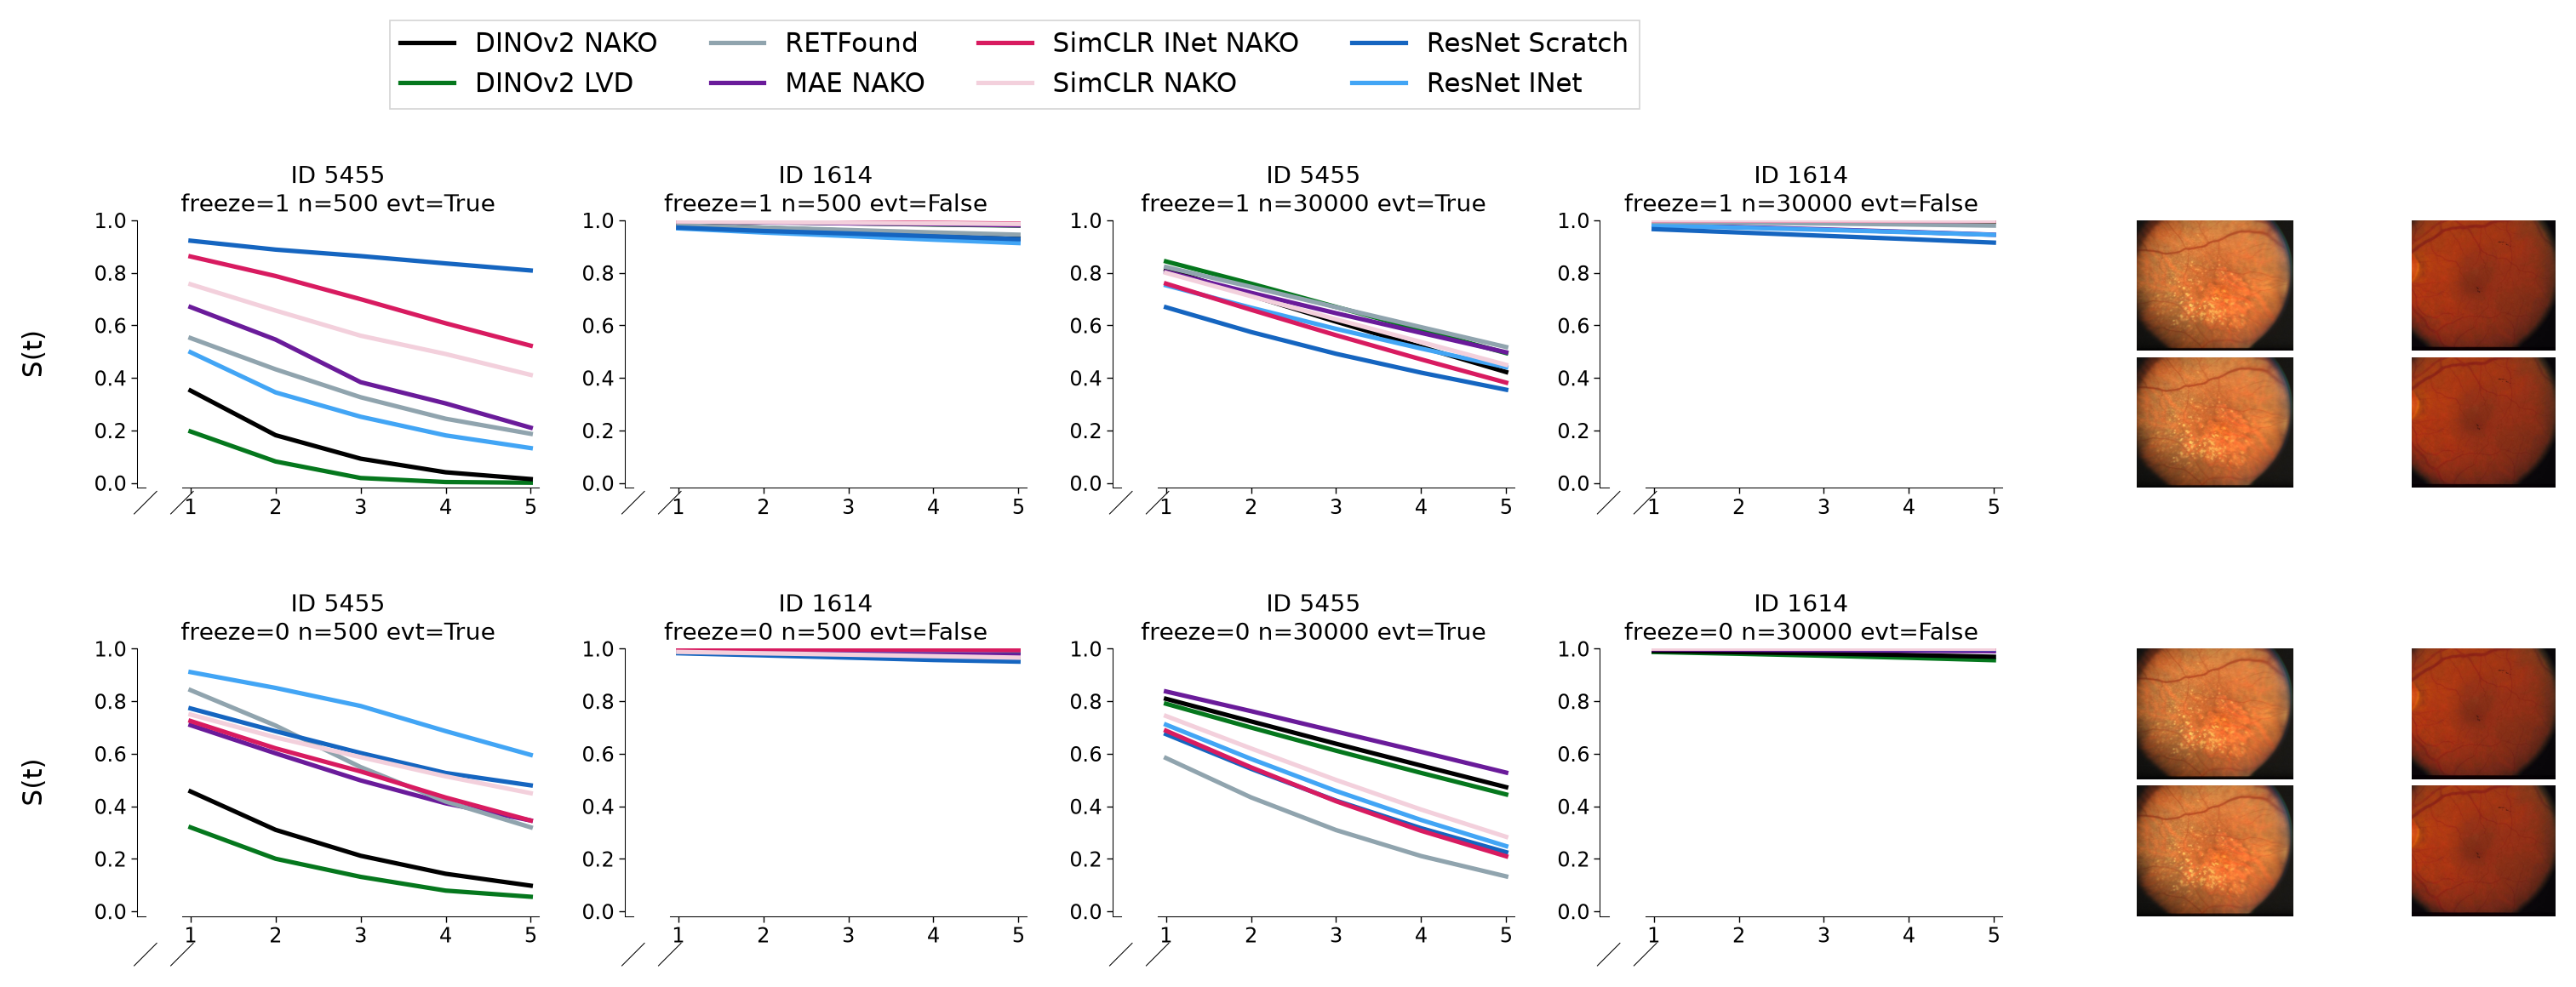

In [44]:
draw_curves_grid_simple(records, image_dir=img_dir, show_images=True,
                         save_path=RESULTS_DIR, stylef=stylef)